# Solution Exercise 2.2

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Grouping data using categorical variables. Applying aggregation functions (sum, mean, count, etc.).
# We could also use other libraries like seaborn
# https://www.freecodecamp.org/news/pandas-dataframe-groupby-method/

In [3]:
df = pd.read_csv("../data/supermarket_sales-Sheet1.csv")
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [4]:
df['Branch'].unique()

array(['A', 'C', 'B'], dtype=object)

In [5]:
# a) Compute the sum, mean and count of “quantity”, grouped by payment method (with df.groupby). Comment on the results
print("Count, Sum and mean:")
print(df.groupby('Payment')['Quantity'].agg(['sum', 'mean','count']))
# Or
# print(df.groupby('Payment').agg(mean_quantity=('Quantity','mean'),
#                                 sum_quantity=('Quantity','sum'),
#                                 count_quantity=('Quantity','count')))
# Comments: 
# More payments were made by Ewallet and Cash (counts of transactions: 345 and 344 vs 311 by credit card). 
# In total, more products were purchased by cash (1896 products), although the mean quantity of products purchased per transaction was higher with the credit card (5.536977)
# Warning, we did not show significant difference by statistical test, we do not hypothesize on the population here, just analyze the sample.

Count, Sum and mean:
              sum      mean  count
Payment                           
Cash         1896  5.511628    344
Credit card  1722  5.536977    311
Ewallet      1892  5.484058    345


In [ ]:
# b) Obtain the same mean quantity grouped by payment with a simple pivot table
df.pivot_table(values = 'Quantity', index = 'Payment', aggfunc='mean')

,Quantity
Payment,
Cash,5.511628
Credit card,5.536977
Ewallet,5.484058


In [7]:
# c) Compute the count per Customer type and per City with a pivot table
pivottable = df.pivot_table(values = 'Invoice ID', index = ['City','Customer type'],aggfunc="count")
pivottable
# Comments: For the count aggregation, it doesn't matter which values we use (if there are no NaNs). 
# We can replace e.g. 'Invoice ID' by 'Payment'.

Invoice ID
City      Customer type            
Mandalay  Member                165
          Normal                167
Naypyitaw Member                169
          Normal                159
Yangon    Member                167
          Normal                173

In [8]:
# c) We can play with index and columns to present the data in any way we want (e.g. replace index by columns)
pivottable = df.pivot_table(index='City', columns='Customer type', values='Invoice ID',aggfunc="count")
pivottable

Customer type,Member,Normal
City,,
Mandalay,165,167
Naypyitaw,169,159
Yangon,167,173


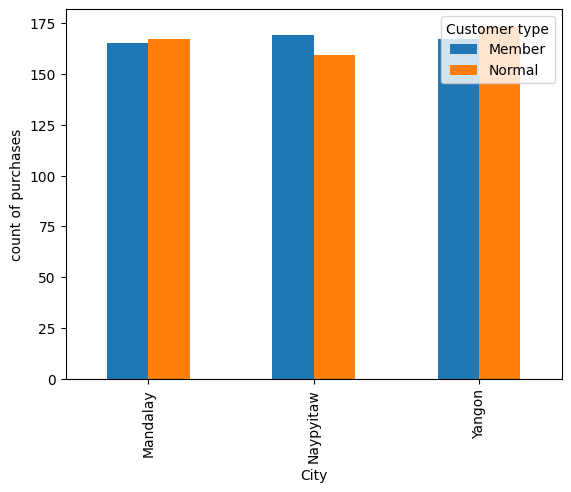

In [9]:
# c) We could make a barplot of this pivot table with the City on the x axis and a different color for Member/Normal. But we will see that in details later
ax = pivottable.plot.bar(ylabel='count of purchases')
# plt.xticks(rotation=45, ha='right')
plt.show()


In [10]:
# c) Yet another table
pivottable = df.pivot_table(columns=['Customer type','City'], values='Invoice ID',aggfunc="count")
pivottable

Customer type   Member                    Normal                 
City          Mandalay Naypyitaw Yangon Mandalay Naypyitaw Yangon
Invoice ID         165       169    167      167       159    173